# Vicon Marker CSV Visualizer

This notebook plots **only Vicon marker trajectory data** from the `Trajectories` block of each CSV.

## Marker Notes

Useful references:
- Vicon Plug-in Gait Reference Guide: https://help.vicon.com/download/attachments/11378719/Plug-in%20Gait%20Reference%20Guide.pdf

Marker names in these files:

| Marker | Meaning |
|---|---|
| LASIS | Left anterior superior iliac spine |
| RASIS | Right anterior superior iliac spine |
| LPSIS | Left posterior superior iliac spine |
| RPSIS | Right posterior superior iliac spine |
| RLEK | Right lateral epicondyle of knee |
| LLEK | Left lateral epicondyle of knee |
| RMM | Right medial malleolus |
| LMM | Left medial malleolus |
| RHEE | Right heel |
| LHEE | Left heel |
| RMT2 | Right second metatarsal |
| LMT2 | Left second metatarsal |
| RSHO | Right shoulder |
| LSHO | Left shoulder |

Note: Vicon's standard Plug-in Gait labels are often shorter, for example `LASI` and `RASI`; this dataset uses labels such as `LASIS`/`RASIS`, which are interpreted as the same anatomical landmarks.

## Imports and Settings

In [1]:
from pathlib import Path
import csv

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

pd.set_option("display.max_columns", 80)

DEFAULT_VICON_VISIT_DIR = Path("../Data_Sensors/Vicon_CSV_Files/SRS18/visit1")

# Axis visibility flags. Change these and rerun plot cells.
SHOW_X = True
SHOW_Y = True
SHOW_Z = True

# Plot every Nth frame if plots are too dense. Use 1 for full data.
DOWNSAMPLE = 1

# Separate figures by marker can be easier to read, but creates many plots.
SEPARATE_FIGURE_PER_MARKER = False

# X-axis tick spacing for easier visual time measurement.
# Major ticks get labels; minor ticks are small unlabeled tick marks.
X_MAJOR_TICK_INTERVAL_S = 1.0
X_MINOR_TICK_INTERVAL_S = 0.1

## Vicon Trajectory Parser

In [2]:
MARKER_FULL_FORMS = {
    "LASIS": "Left anterior superior iliac spine",
    "RASIS": "Right anterior superior iliac spine",
    "LPSIS": "Left posterior superior iliac spine",
    "RPSIS": "Right posterior superior iliac spine",
    "RLEK": "Right lateral epicondyle of knee",
    "LLEK": "Left lateral epicondyle of knee",
    "RMM": "Right medial malleolus",
    "LMM": "Left medial malleolus",
    "RHEE": "Right heel",
    "LHEE": "Left heel",
    "RMT2": "Right second metatarsal",
    "LMT2": "Left second metatarsal",
    "RSHO": "Right shoulder",
    "LSHO": "Left shoulder",
}


def find_activity_csvs(root, activity_prefix):
    root = Path(root)
    if not root.exists():
        return []
    prefix = activity_prefix.lower()
    files = []
    for path in root.rglob("*.csv"):
        parent = path.parent.name.lower()
        stem = path.stem.lower()
        if parent.startswith(prefix) or stem.startswith(prefix):
            files.append(path)
    return sorted(files)


def default_activity_file(root, activity_prefix):
    files = find_activity_csvs(root, activity_prefix)
    if not files:
        return None
    return files[0]


def _clean_marker_name(raw_name):
    name = str(raw_name).strip()
    if ":" in name:
        name = name.split(":", 1)[1]
    return name


def load_vicon_marker_trajectories(csv_path):
    """Load only the Vicon Trajectories marker block from a CSV file."""
    csv_path = Path(csv_path)
    with csv_path.open("r", encoding="utf-8-sig", errors="replace", newline="") as f:
        rows = list(csv.reader(f))

    traj_idx = None
    for i, row in enumerate(rows):
        if row and row[0].strip().lower() == "trajectories":
            traj_idx = i
            break
    if traj_idx is None:
        raise ValueError(f"No Trajectories block found in {csv_path}")

    fs_hz = pd.to_numeric(pd.Series([rows[traj_idx + 1][0] if rows[traj_idx + 1] else np.nan]), errors="coerce").iloc[0]
    if pd.isna(fs_hz) or fs_hz <= 0:
        fs_hz = np.nan

    marker_row = rows[traj_idx + 2]
    axis_row = rows[traj_idx + 3]
    unit_row = rows[traj_idx + 4]
    data_rows = rows[traj_idx + 5:]

    marker_cols = []
    for col_idx, raw_name in enumerate(marker_row):
        if str(raw_name).strip():
            marker_cols.append((col_idx, _clean_marker_name(raw_name)))

    records = []
    for row in data_rows:
        if len(row) < 2:
            continue
        frame = pd.to_numeric(pd.Series([row[0]]), errors="coerce").iloc[0]
        sub_frame = pd.to_numeric(pd.Series([row[1]]), errors="coerce").iloc[0]
        if pd.isna(frame):
            continue
        record = {"frame": int(frame), "sub_frame": int(sub_frame) if pd.notna(sub_frame) else 0}
        for start_col, marker in marker_cols:
            values = []
            for offset in range(3):
                idx = start_col + offset
                value = row[idx] if idx < len(row) else ""
                values.append(pd.to_numeric(pd.Series([value]), errors="coerce").iloc[0])
            record[f"{marker}_X"] = values[0]
            record[f"{marker}_Y"] = values[1]
            record[f"{marker}_Z"] = values[2]
        records.append(record)

    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError(f"No trajectory rows found in {csv_path}")

    if np.isfinite(fs_hz):
        df["time_s"] = (df["frame"] - df["frame"].iloc[0]) / float(fs_hz)
    else:
        df["time_s"] = np.arange(len(df), dtype=float)

    markers = [marker for _, marker in marker_cols]
    units = "mm" if any("mm" in str(x).lower() for x in unit_row) else "unknown"
    meta = {
        "csv_path": csv_path,
        "fs_hz": float(fs_hz) if np.isfinite(fs_hz) else np.nan,
        "markers": markers,
        "units": units,
        "trajectory_start_line": traj_idx + 1,
    }
    return df, meta


def marker_summary(meta):
    rows = []
    for marker in meta["markers"]:
        rows.append({"marker": marker, "meaning": MARKER_FULL_FORMS.get(marker, "Unknown / custom marker")})
    return pd.DataFrame(rows)


def selected_markers(meta, manual_markers=None, marker_visibility=None):
    manual_markers = list(manual_markers or [])
    if manual_markers:
        return [m for m in manual_markers if m in meta["markers"]]
    marker_visibility = marker_visibility or {}
    return [m for m in meta["markers"] if marker_visibility.get(m, True)]


def _apply_x_time_ticks(ax, major_interval_s=1.0, minor_interval_s=0.1):
    if major_interval_s and major_interval_s > 0:
        ax.xaxis.set_major_locator(MultipleLocator(major_interval_s))
    if minor_interval_s and minor_interval_s > 0:
        ax.xaxis.set_minor_locator(MultipleLocator(minor_interval_s))
        ax.tick_params(axis="x", which="minor", length=4, width=0.8, color="0.25")
    ax.tick_params(axis="x", which="major", length=7, width=1.0)


def plot_marker_axes(
    df,
    meta,
    title=None,
    markers=None,
    marker_visibility=None,
    show_x=True,
    show_y=True,
    show_z=True,
    downsample=1,
    separate=False,
    x_major_tick_interval_s=1.0,
    x_minor_tick_interval_s=0.1,
):
    markers = selected_markers(meta, manual_markers=markers, marker_visibility=marker_visibility)
    if not markers:
        print("No selected markers found in file.")
        return

    axes = []
    if show_x:
        axes.append("X")
    if show_y:
        axes.append("Y")
    if show_z:
        axes.append("Z")
    if not axes:
        print("All axis flags are False. Set SHOW_X, SHOW_Y, or SHOW_Z to True.")
        return

    step = max(int(downsample), 1)
    plot_df = df.iloc[::step].copy()
    time_s = plot_df["time_s"].to_numpy(dtype=float)
    units = meta.get("units", "unknown")
    title = title or Path(meta["csv_path"]).stem

    if separate:
        for marker in markers:
            fig, ax = plt.subplots(figsize=(13, 4))
            for axis in axes:
                col = f"{marker}_{axis}"
                if col in plot_df:
                    ax.plot(time_s, plot_df[col], label=f"{marker} {axis}")
            _apply_x_time_ticks(ax, x_major_tick_interval_s, x_minor_tick_interval_s)
            ax.set_title(f"{title}: {marker} ({MARKER_FULL_FORMS.get(marker, 'custom marker')})")
            ax.set_xlabel("Time (s)")
            ax.set_ylabel(f"Position ({units})")
            ax.grid(True, alpha=0.3)
            ax.legend(loc="best", fontsize=8)
            plt.tight_layout()
            plt.show()
        return

    fig, axs = plt.subplots(len(axes), 1, figsize=(14, 3.5 * len(axes)), sharex=True)
    if len(axes) == 1:
        axs = [axs]
    for ax_obj, axis in zip(axs, axes):
        for marker in markers:
            col = f"{marker}_{axis}"
            if col in plot_df:
                ax_obj.plot(time_s, plot_df[col], label=marker)
        _apply_x_time_ticks(ax_obj, x_major_tick_interval_s, x_minor_tick_interval_s)
        ax_obj.set_title(f"{title}: {axis} axis marker trajectories")
        ax_obj.set_ylabel(f"{axis} position ({units})")
        ax_obj.grid(True, alpha=0.3)
        ax_obj.legend(loc="upper right", fontsize=8, ncol=2)
    axs[-1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()


## Select Default Files

In [3]:
STS_FILE = default_activity_file(DEFAULT_VICON_VISIT_DIR, "STS")
TURN_LEFT_FILE = default_activity_file(DEFAULT_VICON_VISIT_DIR, "TURNL")
TURN_RIGHT_FILE = default_activity_file(DEFAULT_VICON_VISIT_DIR, "TURNR")
NW_FILE = default_activity_file(DEFAULT_VICON_VISIT_DIR, "NW")

print("Vicon visit folder:", DEFAULT_VICON_VISIT_DIR)
print("STS file:", STS_FILE)
print("TURN left file:", TURN_LEFT_FILE)
print("TURN right file:", TURN_RIGHT_FILE)
print("NW file:", NW_FILE)

# You can override manually, for example:
# DEFAULT_VICON_VISIT_DIR = Path("../Data_Sensors/Vicon_CSV_Files/SRS01/visit2")
# DEFAULT_VICON_VISIT_DIR = Path("../Data_Sensors/Vicon_CSV_Files/SRS02/visit1")
# STS_FILE = Path("../Data_Sensors/Vicon_CSV_Files/SRS01/visit1/STS03/STS03.csv")
# TURN_LEFT_FILE = Path("../Data_Sensors/Vicon_CSV_Files/SRS01/visit1/TURNL03/TURNL03.csv")
# TURN_RIGHT_FILE = Path("../Data_Sensors/Vicon_CSV_Files/SRS01/visit1/TURNR02/TURNR02.csv")
# NW_FILE = Path("../Data_Sensors/Vicon_CSV_Files/SRS01/visit1/NW03/NW03.csv")

Vicon visit folder: ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1
STS file: ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1/STS01/STS01.csv
TURN left file: ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1/TurnL03/TurnL03.csv
TURN right file: ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1/TurnR02/TurnR02.csv
NW file: ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1/NW01/NW01.csv


## Marker Summary


In [4]:
summary_file = next((p for p in [STS_FILE, TURN_LEFT_FILE, TURN_RIGHT_FILE, NW_FILE] if p is not None), None)
if summary_file is None:
    print("No Vicon CSV found for marker summary.")
else:
    _, summary_meta = load_vicon_marker_trajectories(summary_file)
    print(f"Marker summary from: {summary_file}")
    display(marker_summary(summary_meta))

Marker summary from: ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1/STS01/STS01.csv


,marker,meaning
0,LASIS,Left anterior superior iliac spine
1,RASIS,Right anterior superior iliac spine
2,LPSIS,Left posterior superior iliac spine
3,RPSIS,Right posterior superior iliac spine
4,RLEK,Right lateral epicondyle of knee
5,RMM,Right medial malleolus
6,RHEE,Right heel
7,RMT2,Right second metatarsal
8,LLEK,Left lateral epicondyle of knee
9,LMM,Left medial malleolus


## STS Marker Plot

Marker flags for this plot are inside the cell below.

Loaded ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1/STS01/STS01.csv
Sampling frequency: 100.0 Hz | markers: 14 | units: mm


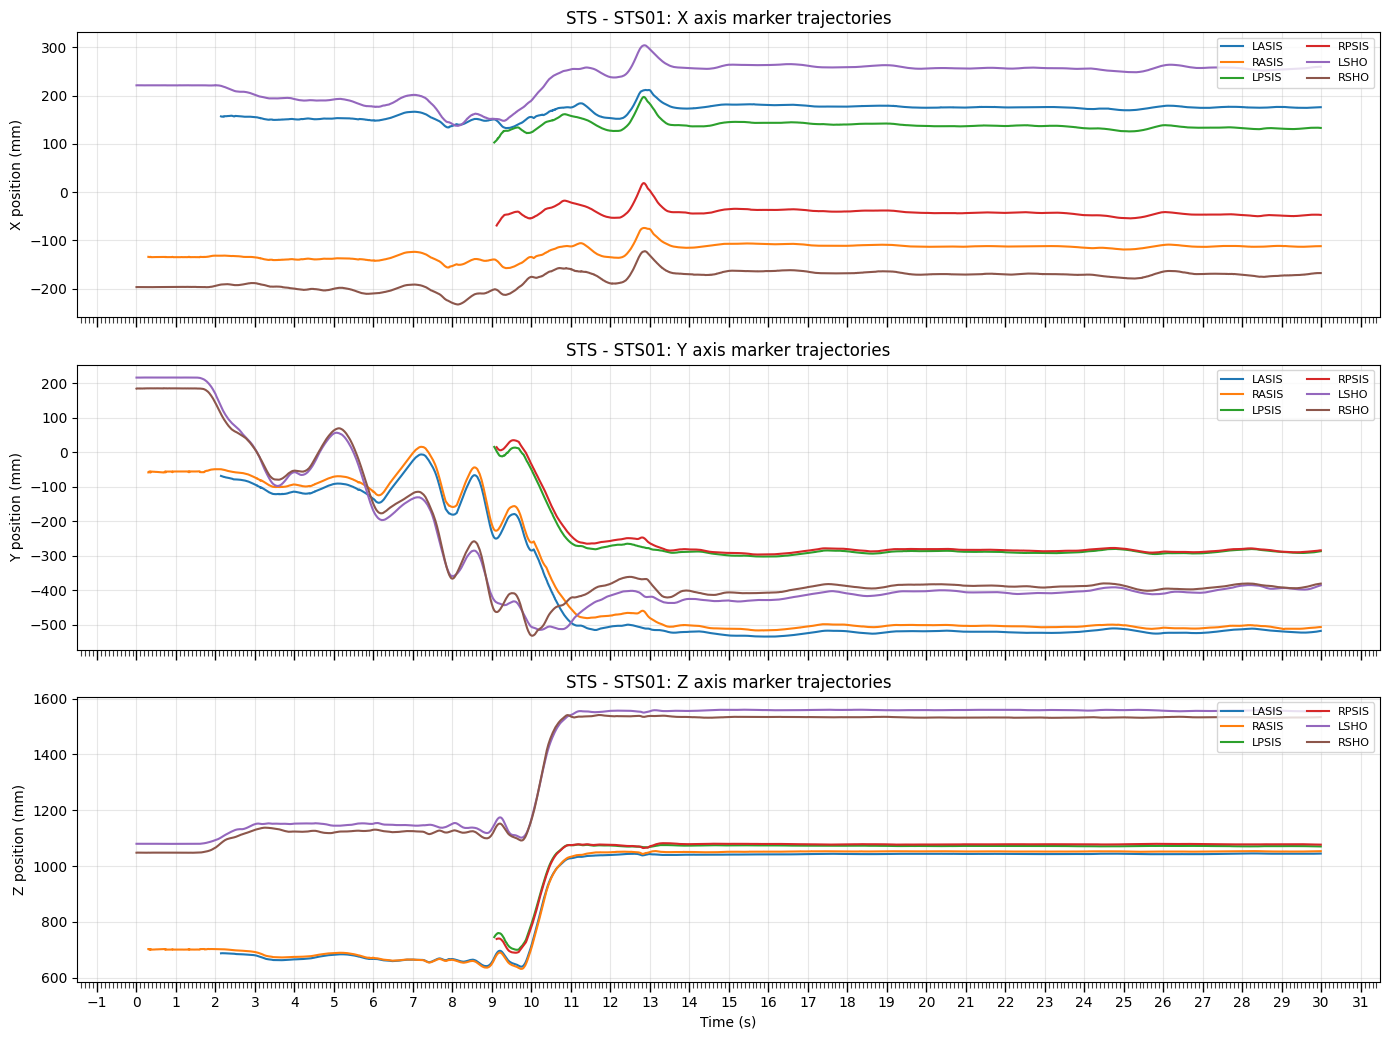

In [5]:
# Toggle markers for this plot only.
# True = show marker, False = hide marker.
STS_MARKERS = {
    "LASIS": True,
    "RASIS": True,
    "LPSIS": True,
    "RPSIS": True,
    "RLEK": False,
    "RMM": False,
    "RHEE": False,
    "RMT2": False,
    "LLEK": False,
    "LMM": False,
    "LHEE": False,
    "LMT2": False,
    "LSHO": True,
    "RSHO": True,
}

if STS_FILE is None:
    print("No STS CSV found.")
else:
    sts_df, sts_meta = load_vicon_marker_trajectories(STS_FILE)
    print(f"Loaded {STS_FILE}")
    print(f"Sampling frequency: {sts_meta['fs_hz']} Hz | markers: {len(sts_meta['markers'])} | units: {sts_meta['units']}")
    plot_marker_axes(
        sts_df,
        sts_meta,
        title=f"STS - {STS_FILE.parent.name}",
        markers=[],
        marker_visibility=STS_MARKERS,
        show_x=SHOW_X,
        show_y=SHOW_Y,
        show_z=SHOW_Z,
        downsample=DOWNSAMPLE,
        separate=SEPARATE_FIGURE_PER_MARKER,
        x_major_tick_interval_s=X_MAJOR_TICK_INTERVAL_S,
        x_minor_tick_interval_s=X_MINOR_TICK_INTERVAL_S,
    )

## Left TURN Marker Plot

Marker flags for this plot are inside the cell below.

Loaded ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1/TurnL03/TurnL03.csv
Sampling frequency: 100.0 Hz | markers: 14 | units: mm


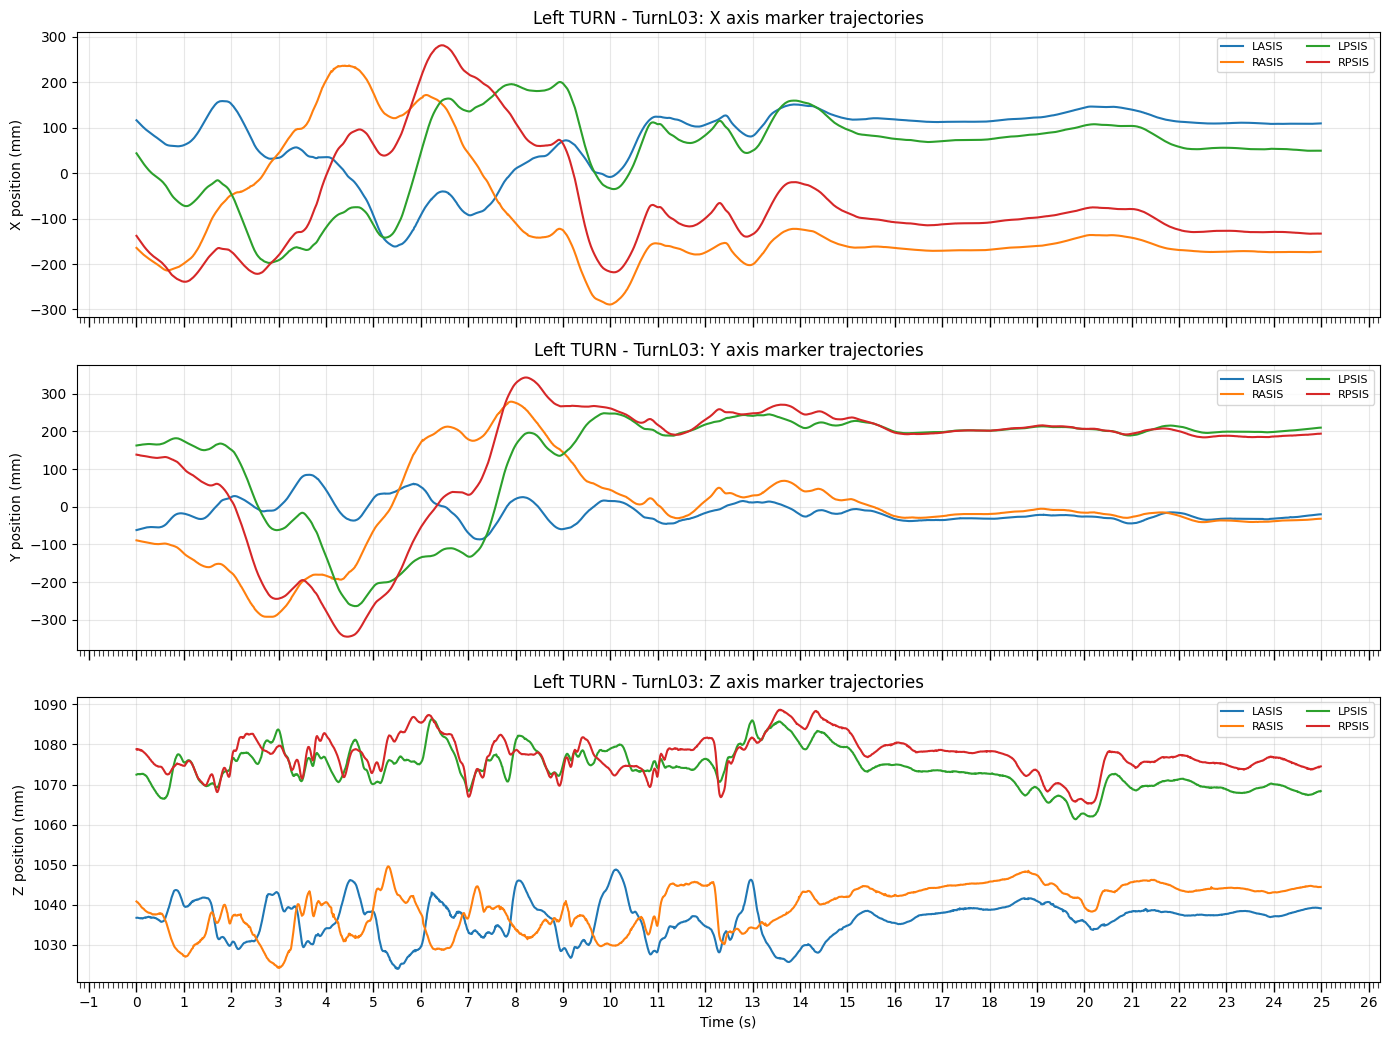

In [6]:
# Toggle markers for this plot only.
# True = show marker, False = hide marker.
LEFT_TURN_MARKERS = {
    "LASIS": True,
    "RASIS": True,
    "LPSIS": True,
    "RPSIS": True,
    "RLEK": False,
    "RMM": False,
    "RHEE": False,
    "RMT2": False,
    "LMT2": False,
    "LLEK": False,
    "LMM": False,
    "LHEE": False,
    "LSHO": False,
    "RSHO": False,
}

if TURN_LEFT_FILE is None:
    print("No left TURN CSV found.")
else:
    turn_left_df, turn_left_meta = load_vicon_marker_trajectories(TURN_LEFT_FILE)
    print(f"Loaded {TURN_LEFT_FILE}")
    print(f"Sampling frequency: {turn_left_meta['fs_hz']} Hz | markers: {len(turn_left_meta['markers'])} | units: {turn_left_meta['units']}")
    plot_marker_axes(
        turn_left_df,
        turn_left_meta,
        title=f"Left TURN - {TURN_LEFT_FILE.parent.name}",
        markers=[],
        marker_visibility=LEFT_TURN_MARKERS,
        show_x=SHOW_X,
        show_y=SHOW_Y,
        show_z=SHOW_Z,
        downsample=DOWNSAMPLE,
        separate=SEPARATE_FIGURE_PER_MARKER,
        x_major_tick_interval_s=X_MAJOR_TICK_INTERVAL_S,
        x_minor_tick_interval_s=X_MINOR_TICK_INTERVAL_S,
    )

## Right TURN Marker Plot

Marker flags for this plot are inside the cell below.

Loaded ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1/TurnR02/TurnR02.csv
Sampling frequency: 100.0 Hz | markers: 14 | units: mm


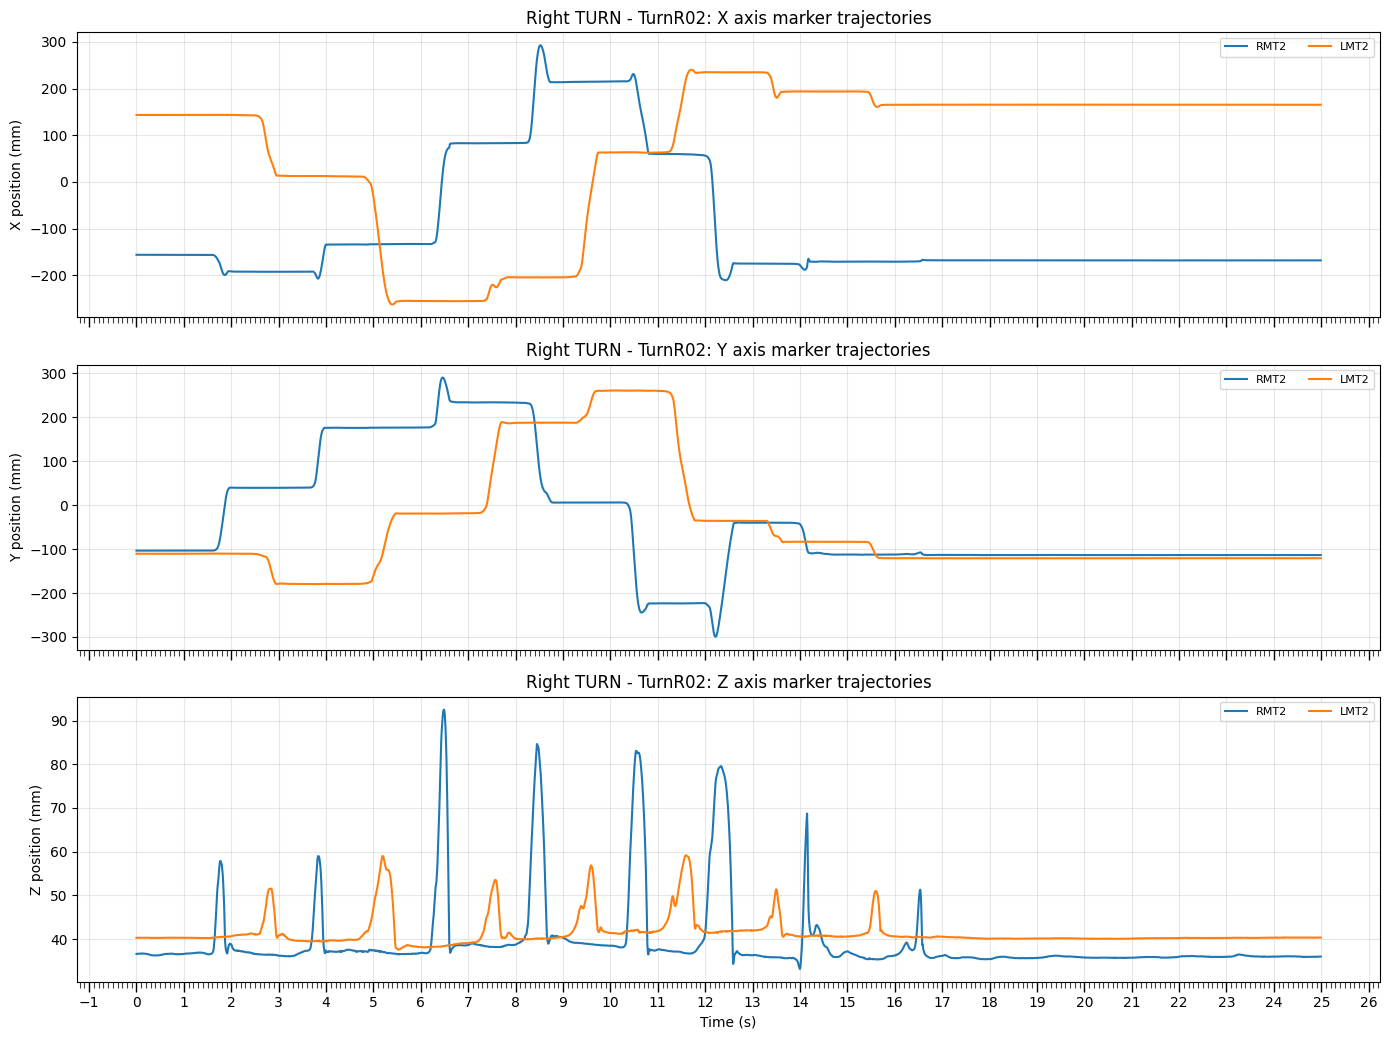

In [7]:
# Toggle markers for this plot only.
# True = show marker, False = hide marker.
RIGHT_TURN_MARKERS = {
    "LASIS": False,
    "RASIS": False,
    "LPSIS": False,
    "RPSIS":False,
    "RLEK": False,
    "RMM": False,
    "RHEE": False,
    "RMT2": True,
    "LMT2": True,
    "LLEK": False,
    "LMM": False,
    "LHEE": False,
    "LSHO": False,
    "RSHO": False,
}

if TURN_RIGHT_FILE is None:
    print("No right TURN CSV found.")
else:
    turn_right_df, turn_right_meta = load_vicon_marker_trajectories(TURN_RIGHT_FILE)
    print(f"Loaded {TURN_RIGHT_FILE}")
    print(f"Sampling frequency: {turn_right_meta['fs_hz']} Hz | markers: {len(turn_right_meta['markers'])} | units: {turn_right_meta['units']}")
    plot_marker_axes(
        turn_right_df,
        turn_right_meta,
        title=f"Right TURN - {TURN_RIGHT_FILE.parent.name}",
        markers=[],
        marker_visibility=RIGHT_TURN_MARKERS,
        show_x=SHOW_X,
        show_y=SHOW_Y,
        show_z=SHOW_Z,
        downsample=DOWNSAMPLE,
        separate=SEPARATE_FIGURE_PER_MARKER,
        x_major_tick_interval_s=X_MAJOR_TICK_INTERVAL_S,
        x_minor_tick_interval_s=X_MINOR_TICK_INTERVAL_S,
    )

## NW Marker Plot

Marker flags for this plot are inside the cell below.

Loaded ../Data_Sensors/Vicon_CSV_Files/SRS18/visit1/NW01/NW01.csv
Sampling frequency: 100.0 Hz | markers: 14 | units: mm


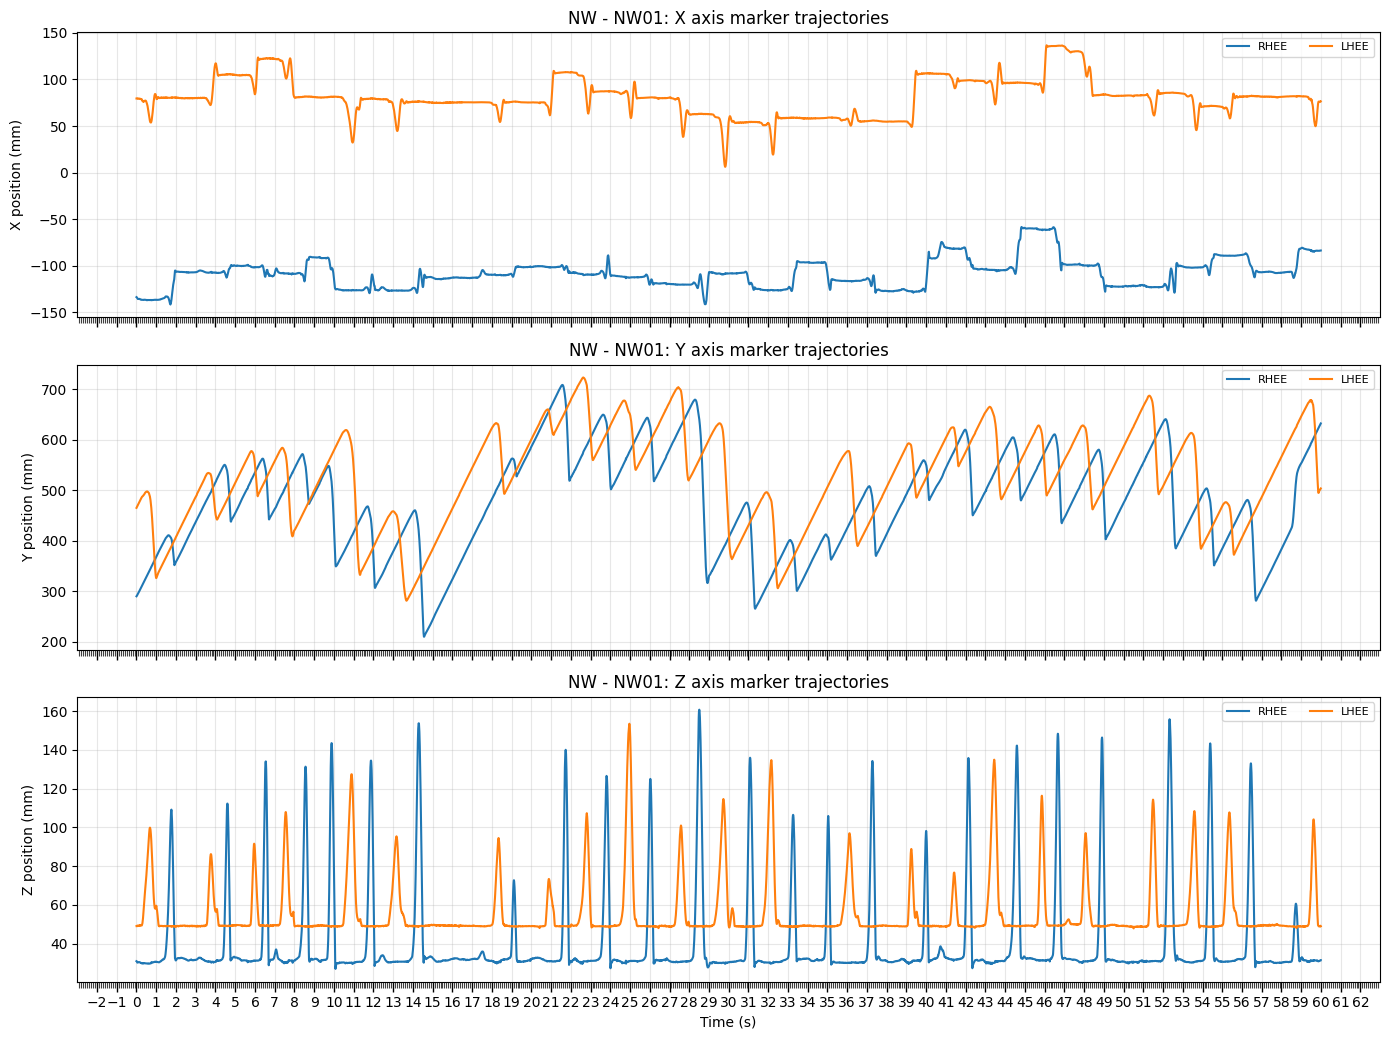

In [8]:
# Toggle markers for this plot only.
# True = show marker, False = hide marker.
NW_MARKERS = {
    "LASIS": False,
    "RASIS": False,
    "LPSIS": False,
    "RPSIS": False,
    "RLEK": False,
    "RMM": False,
    "RHEE": True,
    "RMT2": False,
    "LLEK": False,
    "LMM": False,
    "LHEE": True,
    "LMT2": False,
    "LSHO": False,
    "RSHO": False,
}

if NW_FILE is None:
    print("No NW CSV found.")
else:
    nw_df, nw_meta = load_vicon_marker_trajectories(NW_FILE)
    print(f"Loaded {NW_FILE}")
    print(f"Sampling frequency: {nw_meta['fs_hz']} Hz | markers: {len(nw_meta['markers'])} | units: {nw_meta['units']}")
    plot_marker_axes(
        nw_df,
        nw_meta,
        title=f"NW - {NW_FILE.parent.name}",
        markers=[],
        marker_visibility=NW_MARKERS,
        show_x=SHOW_X,
        show_y=SHOW_Y,
        show_z=SHOW_Z,
        downsample=DOWNSAMPLE,
        separate=SEPARATE_FIGURE_PER_MARKER,
        x_major_tick_interval_s=X_MAJOR_TICK_INTERVAL_S,
        x_minor_tick_interval_s=X_MINOR_TICK_INTERVAL_S,
    )